# RQ3 Analysis (scalability of CRUD operations)

In [31]:
def shorten_x_axis_labels(ax):
    labels = [t.get_text() for t in ax.get_xticklabels()]

    new_labels = []
    for l in labels:
        try:
            val = float(l)

            if val >= 1_000_000:
                new_labels.append(f"{int(val/1_000_000)}M")
            elif val >= 1_000:
                new_labels.append(f"{int(val/1_000)}K")
            else:
                new_labels.append(str(int(val)))

        except:
            new_labels.append(l)

    ax.set_xticklabels(new_labels, rotation=0)

## Results

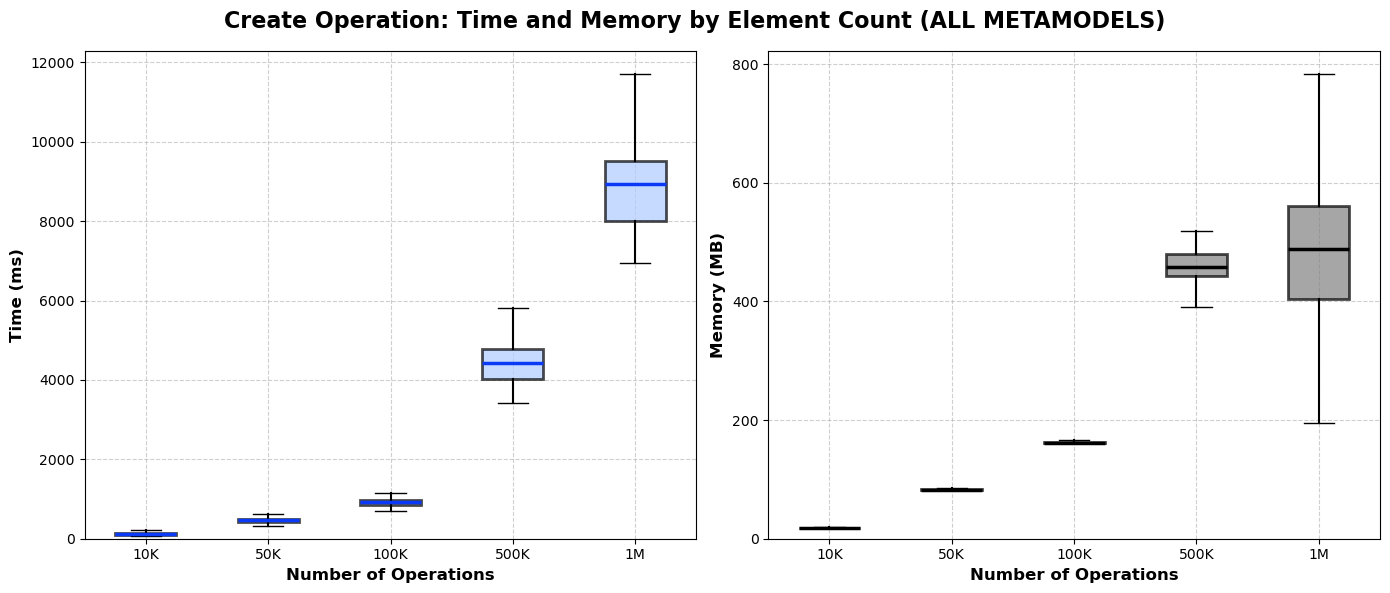

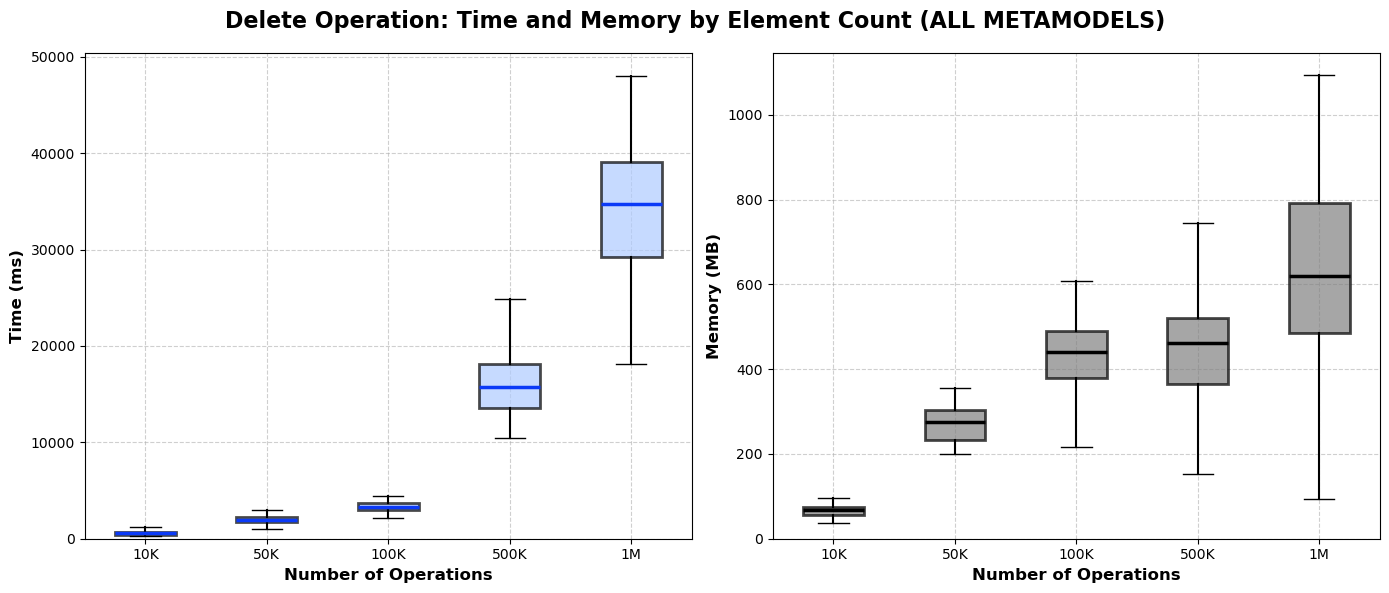

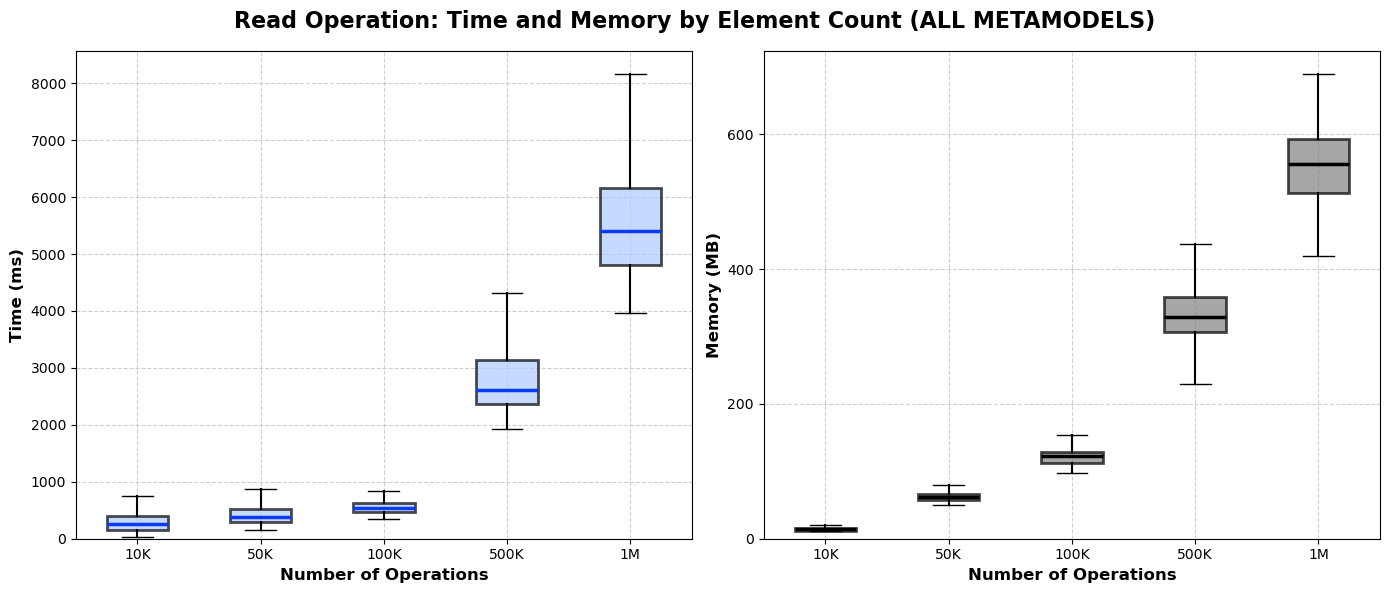

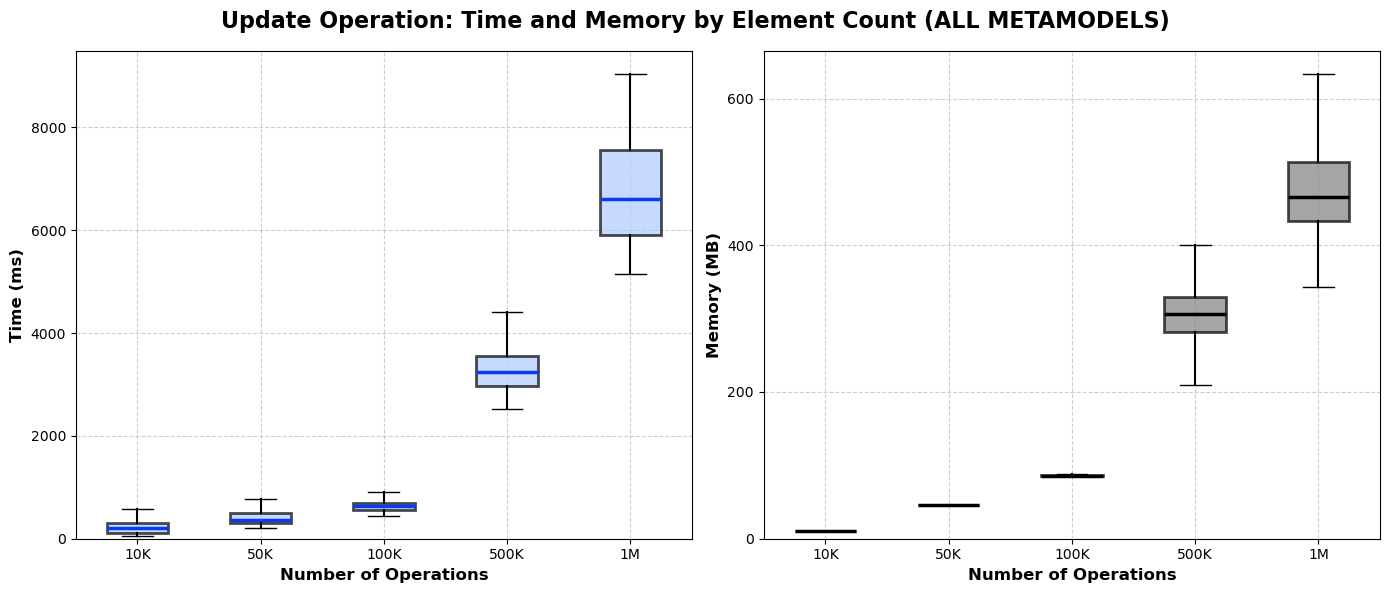

In [32]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

BASE_FOLDER = "../results/RQ3GenModels"

group_col = "element_count"
pattern = re.compile(r"(.+)_run_\d+\.csv")


def plot_operation(df, op_name, metamodel_name):
    #df["time"] = df["time"] / 1000  
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # -------- TIME --------
    df.boxplot(
        column="time",
        by=group_col,
        ax=axes[0],
        patch_artist=True,
        showfliers=False,
        boxprops=dict(facecolor="#AFCBFF", color="black", linewidth=2, alpha=0.7),
        medianprops=dict(color="#0B3AF7", linewidth=2.5),
        whiskerprops=dict(color="black", linewidth=1.5),
    )

    axes[0].set_title("")
    axes[0].set_xlabel("Number of Operations", fontsize=12, fontweight="bold")
    axes[0].set_ylabel("Time (ms)", fontsize=12, fontweight="bold")
    axes[0].grid(True, linestyle="--", alpha=0.6)
    axes[0].set_ylim(bottom=0)

    # -------- MEM --------
    df.boxplot(
        column="mem",
        by=group_col,
        ax=axes[1],
        patch_artist=True,
        showfliers=False,
        boxprops=dict(facecolor="gray", color="black", linewidth=2, alpha=0.7),
        medianprops=dict(color="black", linewidth=2.5),
        whiskerprops=dict(color="black", linewidth=1.5),
    )

    axes[1].set_xlabel("Number of Operations", fontsize=12, fontweight="bold")
    axes[1].set_ylabel("Memory (MB)", fontsize=12, fontweight="bold")

    axes[1].yaxis.set_major_locator(mticker.MultipleLocator(200 * 1024))
    axes[1].yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"{int(x / 1024)}")
    )

    axes[1].grid(True, linestyle="--", alpha=0.6)
    axes[1].set_ylim(bottom=0)
    axes[1].set_title("")

    shorten_x_axis_labels(axes[0])
    shorten_x_axis_labels(axes[1])
    axes[0].set_ylim(bottom=0)
    axes[1].set_ylim(bottom=0)

    plt.suptitle(
        f"{op_name} Operation: Time and Memory by Element Count ({metamodel_name})",
        fontsize=16,
        fontweight="bold",
    )

    plt.tight_layout()

    plt.show()


# ---------------- main loop -

operations = {}

for metamodel in os.listdir(BASE_FOLDER):
    folder_path = os.path.join(BASE_FOLDER, metamodel)

    if not os.path.isdir(folder_path):
        continue
 

    for file in os.listdir(folder_path):
        if not file.endswith(".csv"):
            continue

        match = pattern.match(file)
        if not match:
            continue

        op = match.group(1)

        df = pd.read_csv(os.path.join(folder_path, file))
        df["metamodel"] = metamodel  # kept for traceability (not used in plot)

        operations.setdefault(op, []).append(df)


for op, dfs in operations.items():
    full_df = pd.concat(dfs, ignore_index=True)

    # all metamodels combined
    plot_operation(full_df, op, "ALL METAMODELS")

In [33]:
import os
import re
import pandas as pd

BASE_FOLDER = "../results/RQ3GenModels"

group_col = "element_count"
pattern = re.compile(r"(.+)_run_\d+\.csv")


# ---- Helper ----
def remove_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    return series[(series >= q1 - 1.5 * iqr) & (series <= q3 + 1.5 * iqr)]


# ---- LOAD DATA ----
operations = {}

for metamodel in os.listdir(BASE_FOLDER):
    folder_path = os.path.join(BASE_FOLDER, metamodel)

    if not os.path.isdir(folder_path):
        continue

    for file in os.listdir(folder_path):
        if not file.endswith(".csv"):
            continue

        match = pattern.match(file)
        if not match:
            continue

        op = match.group(1)

        df = pd.read_csv(os.path.join(folder_path, file))
        df["metamodel"] = metamodel

        operations.setdefault(op, []).append(df)


# ---- ANALYSIS ----
for op, dfs in operations.items():
    print("\n===================================================")
    print(f"OPERATION: {op}")
    print("===================================================\n")

    df = pd.concat(dfs, ignore_index=True)

    # ---- GLOBAL ----
    print("---- GLOBAL STATS ----")
    for metric in ["time", "mem"]:
        s = df[metric]
        print(f"{metric.upper()}: mean={s.mean():.4f}, median={s.median():.4f}, std={s.std():.4f}, max={s.max():.4f}")
    print()
 

    # ---- PER ELEMENT COUNT ----
    print("---- PER ELEMENT COUNT ----")
    grouped = df.groupby(group_col)

    for val, group in grouped:
        t_mean = remove_outliers(group["time"]).mean()
        m_mean = remove_outliers(group["mem"]).mean()
        print(f"{group_col}={val}: time_mean={t_mean:.4f}, mem_mean={m_mean:.4f}")
    print()
 
    # ---- PER METAMODEL ----
    print("---- PER METAMODEL ----")
    grouped_meta = df.groupby("metamodel")

    for name, group in grouped_meta:
        t_mean = remove_outliers(group["time"]).mean()
        m_mean = remove_outliers(group["mem"]).mean()
        print(f"{name}: time_mean={t_mean:.4f}, mem_mean={m_mean:.4f}, samples={len(group)}")
    print()

    # ---- WORST CASES (PER OPERATION TYPE) ----
    print("---- TOP 5 WORST CASES PER OPERATION TYPE ----")

    metrics = ["time", "mem"]

    for op_type in operations.keys():  # Create / Delete / Update / Read
        print(f"\n================ OPERATION: {op_type} ================")

        df_op = pd.concat(operations[op_type], ignore_index=True)

        for metric in metrics:
            print(f"\nWorst 5 by {metric}:")

            # take more candidates to allow dedup across time/mem later if needed
            candidates = df_op.nlargest(15, metric)

            selected = []
            seen = set()

            for _, row in candidates.iterrows():
                key = (row["metamodel"], row[group_col], row["time"], row["mem"])

                if key in seen:
                    continue

                seen.add(key)
                selected.append(row)

                if len(selected) == 5:
                    break

            result_df = pd.DataFrame(selected)[
                ["metamodel", group_col, "time", "mem"]
            ]

            print(result_df.to_string(index=False))


OPERATION: Create

---- GLOBAL STATS ----
TIME: mean=2963.4493, median=914.0000, std=3344.8470, max=12044.0000
MEM: mean=246561.7011, median=165888.0000, std=205311.4056, max=968858.0000

---- PER ELEMENT COUNT ----
element_count=10000: time_mean=111.8133, mem_mean=18816.8659
element_count=50000: time_mean=461.8158, mem_mean=84500.2431
element_count=100000: time_mean=908.8349, mem_mean=166411.9212
element_count=500000: time_mean=4428.4156, mem_mean=472050.5539
element_count=1000000: time_mean=8827.9343, mem_mean=489137.5796

---- PER METAMODEL ----
ApplauseDsl: time_mean=3116.2400, mem_mean=258519.8000, samples=150
AthenaDSL: time_mean=2859.9400, mem_mean=241725.2067, samples=150
AtsDsl: time_mean=2704.7933, mem_mean=209857.2933, samples=150
CoreDsl: time_mean=2666.3467, mem_mean=228374.5467, samples=150
CssExtDsl: time_mean=2715.8067, mem_mean=245932.5733, samples=150
DialogScript: time_mean=3052.6600, mem_mean=230510.8200, samples=150
EventOrientedLanguage: time_mean=3181.0467, mem_

## Least square method test

In [34]:
import pandas as pd
import numpy as np
import glob
import os
import re
from collections import defaultdict, Counter

base_folder = "../results/RQ3GenModels"
files = glob.glob(os.path.join(base_folder, "**/*.csv"), recursive=True)

pattern = re.compile(r"(.+)_run_\d+\.csv")

# ----------------------------
# GROUP BY OPERATION + METAMODEL
# ----------------------------
grouped = defaultdict(lambda: defaultdict(list))

for f in files:
    filename = os.path.basename(f)
    match = pattern.match(filename)
    if not match:
        continue

    op = match.group(1)
    metamodel = os.path.basename(os.path.dirname(f))

    grouped[op][metamodel].append(f)

print("Files:", len(files))
print("Operations:", len(grouped))


# ----------------------------
# MODELS
# ----------------------------
def r2(y, y_pred):
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    return 1 - ss_res / ss_tot


def fit_linear(x, y):
    A = np.vstack([x, np.ones(len(x))]).T
    coef, _, _, _ = np.linalg.lstsq(A, y, rcond=None)
    return coef, coef[0] * x + coef[1]


def fit_exponential(x, y):
    y_safe = np.where(y <= 0, 1e-9, y)
    logy = np.log(y_safe)
    A = np.vstack([x, np.ones(len(x))]).T
    coef, _, _, _ = np.linalg.lstsq(A, logy, rcond=None)
    b, loga = coef
    a = np.exp(loga)
    return (a, b), a * np.exp(b * x)


def fit_poly(x, y, degree):
    coef = np.polyfit(x, y, degree)
    return coef, np.polyval(coef, x)


def model_complexity(name):
    if name == "linear":
        return 1
    if name == "exponential":
        return 2
    if name.startswith("poly"):
        return int(name.replace("poly", ""))
    return 10


def format_poly(coefs):
    terms = []
    degree = len(coefs) - 1
    for i, c in enumerate(coefs):
        power = degree - i
        if power == 0:
            terms.append(f"{c:.6e}")
        elif power == 1:
            terms.append(f"{c:.6e} * x")
        else:
            terms.append(f"{c:.6e} * x^{power}")
    return " + ".join(terms)


# ----------------------------
# CONFIG
# ----------------------------
metrics = ["time", "mem"]
poly_degrees = [2, 3, 4, 5]

folder_summaries = []


# ----------------------------
# MAIN LOOP
# ----------------------------
for op, meta_map in grouped.items():
    for metamodel, flist in meta_map.items():

        for metric in metrics:

            run_results = []
            per_run_best = []
            per_run_scores = []
            file_scores = []

            coefs_linear = []
            coefs_exp = []
            coefs_poly = {d: [] for d in poly_degrees}

            for f in flist:
                df = pd.read_csv(f)

                x = df["element_count"].values
                y = df[metric].values

                scores = {}

                # ---- models ----
                _, y_lin = fit_linear(x, y)
                scores["linear"] = r2(y, y_lin)

                _, y_exp = fit_exponential(x, y)
                scores["exponential"] = r2(y, y_exp)

                for d in poly_degrees:
                    _, y_poly = fit_poly(x, y, d)
                    scores[f"poly{d}"] = r2(y, y_poly)

                run_results.append(scores)
                per_run_scores.append(scores)
                file_scores.append((f, scores))

                # best model per run
                rounded_scores = {k: round(v, 2) for k, v in scores.items()}
                max_score = max(rounded_scores.values())
                candidates = [k for k, v in rounded_scores.items() if v == max_score]
                best = min(candidates, key=model_complexity)
                per_run_best.append(best)

                # coefficients
                lin_coef, _ = fit_linear(x, y)
                exp_coef, _ = fit_exponential(x, y)

                coefs_linear.append(lin_coef)
                coefs_exp.append(exp_coef)

                for d in poly_degrees:
                    coef, _ = fit_poly(x, y, d)
                    coefs_poly[d].append(coef)

            # ----------------------------
            # AGGREGATION
            # ----------------------------
            df_runs = pd.DataFrame(run_results)
            mean_scores = df_runs.mean()

            mean_lin = np.mean(coefs_linear, axis=0)
            mean_exp = np.mean(coefs_exp, axis=0)
            mean_poly = {d: np.mean(coefs_poly[d], axis=0) for d in poly_degrees}

            counts = Counter(per_run_best)
            best_model = counts.most_common(1)[0][0]
            consistency = counts[best_model] / len(per_run_best)

            eq_linear = f"y = {mean_lin[0]:.6e} * x + {mean_lin[1]:.6e}"
            eq_exp = f"y = {mean_exp[0]:.6e} * exp({mean_exp[1]:.6e} * x)"
            eq_polys = {f"poly{d}": f"y = {format_poly(mean_poly[d])}" for d in poly_degrees}

            equation = {
                "linear": eq_linear,
                "exponential": eq_exp,
                **eq_polys
            }

            # ----------------------------
            # WORST CASE (FIXED)
            # ----------------------------
            worst_file, worst_scores = min(
                file_scores,
                key=lambda x: x[1][best_model]
            )

            worst_model = min(worst_scores, key=worst_scores.get)

            # ----------------------------
            # OUTPUT
            # ----------------------------
            print("\n==============================")
            print("Operation:", op)
            print("Metamodel:", metamodel)
            print("Metric:", metric.upper())

            print("Best model (majority vote):", best_model)
            print("Consistency:", consistency)

            print("\nEquations:")
            for k, v in equation.items():
                print(f"  {k}: {v}")

            print("\nMean R²:")
            print(mean_scores)

            if consistency < 1.0:
                print("\n⚠️ Inconsistent runs")
                print("Per-run best:", per_run_best)
                print("Worst file:", os.path.basename(worst_file))
                print("Worst model in worst file:", worst_model)
                print("Worst scores:", worst_scores)

            folder_summaries.append({
                "operation": op,
                "metamodel": metamodel,
                "metric": metric,
                "best_model": best_model,
                "consistency": consistency,
                "linear_r2": mean_scores["linear"],
                "exponential_r2": mean_scores["exponential"],
                **{f"poly{d}_r2": mean_scores[f"poly{d}"] for d in poly_degrees},
                "worst_file": os.path.basename(worst_file),
                "worst_model": worst_model
            })


# ----------------------------
# SAVE SUMMARY
# ----------------------------
summary_df = pd.DataFrame(folder_summaries)
summary_df.to_csv("RQ3_Gen_trend_analysis.csv", index=False)

print("\nSaved: RQ3_Gen_trend_analysis.csv")

Files: 3600
Operations: 4

Operation: Create
Metamodel: ApplauseDsl
Metric: TIME
Best model (majority vote): linear
Consistency: 0.9333333333333333

Equations:
  linear: y = 9.416228e-03 * x + -9.947557e+00
  exponential: y = 3.318637e+02 * exp(3.794854e-06 * x)
  poly2: y = 5.748031e-10 * x^2 + 8.845090e-03 * x + 3.452081e+01
  poly3: y = 7.499290e-16 * x^3 + -5.598994e-10 * x^2 + 9.246604e-03 * x + 1.885026e+01
  poly4: y = 1.392720e-20 * x^4 + -2.163149e-14 * x^3 + 8.661695e-09 * x^2 + 8.468517e-03 * x + 2.957016e+01
  poly5: y = 9.304850e-27 * x^5 + -1.518847e-21 * x^4 + -1.468542e-14 * x^3 + 7.826119e-09 * x^2 + 8.499455e-03 * x + 2.933754e+01

Mean R²:
linear         0.998407
exponential    0.476062
poly2          0.999837
poly3          0.999971
poly4          1.000000
poly5          1.000000
dtype: float64

⚠️ Inconsistent runs
Per-run best: ['linear', 'linear', 'linear', 'linear', 'linear', 'linear', 'linear', 'poly2', 'linear', 'linear', 'linear', 'linear', 'linear', 'linear'

C:\Users\lamp6\AppData\Local\Temp\ipykernel_7272\2825885864.py:59: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(x, y, degree)
C:\Users\lamp6\AppData\Local\Temp\ipykernel_7272\2825885864.py:59: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(x, y, degree)
C:\Users\lamp6\AppData\Local\Temp\ipykernel_7272\2825885864.py:59: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(x, y, degree)
C:\Users\lamp6\AppData\Local\Temp\ipykernel_7272\2825885864.py:59: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(x, y, degree)
C:\Users\lamp6\AppData\Local\Temp\ipykernel_7272\2825885864.py:59: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(x, y, degree)
C:\Users\lamp6\AppData\Local\Temp\ipykernel_7272\2825885864.py:59: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(x, y, degree)
C:\Users\lamp6\AppData\Local\Temp\ipykernel_7272\2825885864.py:59: RankWarning: Polyfit may be poorly conditione


Operation: Create
Metamodel: AtsDsl
Metric: MEM
Best model (majority vote): poly3
Consistency: 0.8

Equations:
  linear: y = 3.706766e-01 * x + 8.679266e+04
  exponential: y = 6.162702e+04 * exp(2.250203e-06 * x)
  poly2: y = -7.005501e-07 * x^2 + 1.066759e+00 * x + 3.259614e+04
  poly3: y = 1.702335e-12 * x^3 + -3.276318e-06 * x^2 + 1.978194e+00 * x + -2.975931e+03
  poly4: y = 7.083984e-18 * x^4 + -9.681830e-12 * x^3 + 1.414187e-06 * x^2 + 1.582425e+00 * x + 2.476677e+03
  poly5: y = 4.439094e-24 * x^5 + -2.849119e-19 * x^4 + -6.368046e-12 * x^3 + 1.015556e-06 * x^2 + 1.597185e+00 * x + 2.365700e+03

Mean R²:
linear         0.752868
exponential    0.268925
poly2          0.980501
poly3          0.999770
poly4          1.000000
poly5          1.000000
dtype: float64

⚠️ Inconsistent runs
Per-run best: ['poly3', 'poly3', 'poly3', 'poly3', 'poly3', 'poly3', 'poly3', 'poly3', 'poly3', 'poly3', 'poly3', 'poly2', 'poly3', 'poly3', 'poly2', 'poly2', 'poly3', 'poly3', 'poly3', 'poly3', 'pol

C:\Users\lamp6\AppData\Local\Temp\ipykernel_7272\2825885864.py:59: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(x, y, degree)
C:\Users\lamp6\AppData\Local\Temp\ipykernel_7272\2825885864.py:59: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(x, y, degree)
C:\Users\lamp6\AppData\Local\Temp\ipykernel_7272\2825885864.py:59: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(x, y, degree)
C:\Users\lamp6\AppData\Local\Temp\ipykernel_7272\2825885864.py:59: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(x, y, degree)
C:\Users\lamp6\AppData\Local\Temp\ipykernel_7272\2825885864.py:59: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(x, y, degree)
C:\Users\lamp6\AppData\Local\Temp\ipykernel_7272\2825885864.py:59: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(x, y, degree)
C:\Users\lamp6\AppData\Local\Temp\ipykernel_7272\2825885864.py:59: RankWarning: Polyfit may be poorly conditione


Operation: Create
Metamodel: business
Metric: TIME
Best model (majority vote): linear
Consistency: 0.6333333333333333

Equations:
  linear: y = 8.312759e-03 * x + 2.596175e+02
  exponential: y = 5.181198e+02 * exp(3.148894e-06 * x)
  poly2: y = -1.837432e-09 * x^2 + 1.013847e-02 * x + 1.174686e+02
  poly3: y = -4.553758e-15 * x^3 + 5.052768e-09 * x^2 + 7.700378e-03 * x + 2.126242e+02
  poly4: y = -6.855003e-20 * x^4 + 1.056081e-13 * x^3 + -4.033614e-08 * x^2 + 1.153014e-02 * x + 1.598606e+02
  poly5: y = -4.564904e-26 * x^5 + 7.227364e-21 * x^4 + 7.153110e-14 * x^3 + -3.623686e-08 * x^2 + 1.137836e-02 * x + 1.610018e+02

Mean R²:
linear         0.993169
exponential    0.623929
poly2          0.999013
poly3          0.999666
poly4          1.000000
poly5          1.000000
dtype: float64

⚠️ Inconsistent runs
Per-run best: ['linear', 'linear', 'linear', 'linear', 'linear', 'linear', 'poly2', 'linear', 'linear', 'poly2', 'linear', 'linear', 'linear', 'linear', 'poly2', 'linear', 'linear'

...

C:\Users\lamp6\AppData\Local\Temp\ipykernel_7272\2825885864.py:59: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(x, y, degree)
C:\Users\lamp6\AppData\Local\Temp\ipykernel_7272\2825885864.py:59: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(x, y, degree)
C:\Users\lamp6\AppData\Local\Temp\ipykernel_7272\2825885864.py:59: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(x, y, degree)
C:\Users\lamp6\AppData\Local\Temp\ipykernel_7272\2825885864.py:59: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(x, y, degree)
C:\Users\lamp6\AppData\Local\Temp\ipykernel_7272\2825885864.py:59: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(x, y, degree)
C:\Users\lamp6\AppData\Local\Temp\ipykernel_7272\2825885864.py:59: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(x, y, degree)
C:\Users\lamp6\AppData\Local\Temp\ipykernel_7272\2825885864.py:59: RankWarning: Polyfit may be poorly conditione


Operation: Update
Metamodel: SqliteModel
Metric: TIME
Best model (majority vote): poly2
Consistency: 0.4666666666666667

Equations:
  linear: y = 6.409231e-03 * x + 7.334855e+01
  exponential: y = 2.944724e+02 * exp(3.493103e-06 * x)
  poly2: y = -1.377987e-09 * x^2 + 7.778431e-03 * x + -3.325638e+01
  poly3: y = -7.644458e-15 * x^3 + 1.018869e-08 * x^2 + 3.685565e-03 * x + 1.264826e+02
  poly4: y = 7.757796e-20 * x^4 + -1.323145e-13 * x^3 + 6.155524e-08 * x^2 + -6.485751e-04 * x + 1.861951e+02
  poly5: y = 5.423327e-26 * x^5 + -1.244927e-20 * x^4 + -9.182932e-14 * x^3 + 5.668509e-08 * x^2 + -4.682495e-04 * x + 1.848393e+02

Mean R²:
linear         0.991062
exponential    0.526624
poly2          0.998066
poly3          0.999801
poly4          1.000000
poly5          1.000000
dtype: float64

⚠️ Inconsistent runs
Per-run best: ['poly2', 'poly2', 'poly2', 'linear', 'linear', 'poly2', 'linear', 'linear', 'poly2', 'linear', 'linear', 'poly2', 'linear', 'poly2', 'linear', 'poly3', 'poly2', 

C:\Users\lamp6\AppData\Local\Temp\ipykernel_7272\2825885864.py:59: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(x, y, degree)
C:\Users\lamp6\AppData\Local\Temp\ipykernel_7272\2825885864.py:59: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(x, y, degree)
C:\Users\lamp6\AppData\Local\Temp\ipykernel_7272\2825885864.py:59: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(x, y, degree)
C:\Users\lamp6\AppData\Local\Temp\ipykernel_7272\2825885864.py:59: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(x, y, degree)
C:\Users\lamp6\AppData\Local\Temp\ipykernel_7272\2825885864.py:59: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(x, y, degree)
C:\Users\lamp6\AppData\Local\Temp\ipykernel_7272\2825885864.py:59: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(x, y, degree)
C:\Users\lamp6\AppData\Local\Temp\ipykernel_7272\2825885864.py:59: RankWarning: Polyfit may be poorly conditione


Operation: Update
Metamodel: Transformation
Metric: TIME
Best model (majority vote): linear
Consistency: 0.9

Equations:
  linear: y = 5.842823e-03 * x + 3.946954e+01
  exponential: y = 2.906328e+02 * exp(3.377285e-06 * x)
  poly2: y = 1.829516e-10 * x^2 + 5.661038e-03 * x + 5.362319e+01
  poly3: y = -5.315044e-15 * x^3 + 8.225038e-09 * x^2 + 2.815347e-03 * x + 1.646866e+02
  poly4: y = 3.413605e-20 * x^4 + -6.017265e-14 * x^3 + 3.082748e-08 * x^2 + 9.082280e-04 * x + 1.909615e+02
  poly5: y = 2.428567e-26 * x^5 + -6.178169e-21 * x^4 + -4.204339e-14 * x^3 + 2.864662e-08 * x^2 + 9.889779e-04 * x + 1.903543e+02

Mean R²:
linear         0.996899
exponential    0.660968
poly2          0.998741
poly3          0.999842
poly4          1.000000
poly5          1.000000
dtype: float64

⚠️ Inconsistent runs
Per-run best: ['linear', 'linear', 'linear', 'linear', 'linear', 'linear', 'linear', 'linear', 'linear', 'linear', 'linear', 'linear', 'poly2', 'linear', 'linear', 'linear', 'poly2', 'linear'

C:\Users\lamp6\AppData\Local\Temp\ipykernel_7272\2825885864.py:59: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(x, y, degree)
C:\Users\lamp6\AppData\Local\Temp\ipykernel_7272\2825885864.py:59: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(x, y, degree)
C:\Users\lamp6\AppData\Local\Temp\ipykernel_7272\2825885864.py:59: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(x, y, degree)
C:\Users\lamp6\AppData\Local\Temp\ipykernel_7272\2825885864.py:59: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(x, y, degree)
C:\Users\lamp6\AppData\Local\Temp\ipykernel_7272\2825885864.py:59: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(x, y, degree)
C:\Users\lamp6\AppData\Local\Temp\ipykernel_7272\2825885864.py:59: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(x, y, degree)
C:\Users\lamp6\AppData\Local\Temp\ipykernel_7272\2825885864.py:59: RankWarning: Polyfit may be poorly conditione

In [35]:
import pandas as pd

df = pd.read_csv("RQ3_Gen_trend_analysis.csv")

summary = df.groupby("best_model").agg(
    occurrences=("best_model", "count"),
    operations=("operation", lambda x: sorted(x.unique())),
    metamodels=("metamodel", lambda x: sorted(x.unique()))
).reset_index()

for _, row in summary.iterrows():
    ops = ", ".join(row["operations"])
    metas = ", ".join(row["metamodels"])

    print(f"\n{row['best_model']} was found {row['occurrences']} times")
    print(f"  Operations: {ops}")
    print(f"  Metamodels: {metas}")


linear was found 96 times
  Operations: Create, Delete, Read, Update
  Metamodels: ApplauseDsl, AthenaDSL, AtsDsl, CoreDsl, CssExtDsl, DialogScript, EventOrientedLanguage, FlatQVT, FractalItf, Glsl, Iptables, JavaVMTypes, LLVM_IR, MDD, NetModel, OseeDsl, RobotTask, SqliteModel, StaticScript, Transformation, business, environment, erlang, esb, hockeyleague, java5, modelica, reviews, timing-diagram, widget

poly2 was found 85 times
  Operations: Create, Delete, Read, Update
  Metamodels: ApplauseDsl, AthenaDSL, AtsDsl, CoreDsl, CssExtDsl, DialogScript, EventOrientedLanguage, FlatQVT, FractalItf, Glsl, Iptables, JavaVMTypes, LLVM_IR, MDD, NetModel, OseeDsl, RobotTask, SqliteModel, StaticScript, Transformation, business, environment, erlang, esb, hockeyleague, java5, modelica, reviews, timing-diagram, widget

poly3 was found 48 times
  Operations: Create, Delete, Read
  Metamodels: ApplauseDsl, AthenaDSL, AtsDsl, CssExtDsl, DialogScript, EventOrientedLanguage, FlatQVT, FractalItf, Glsl, I

## Reverse Engineered

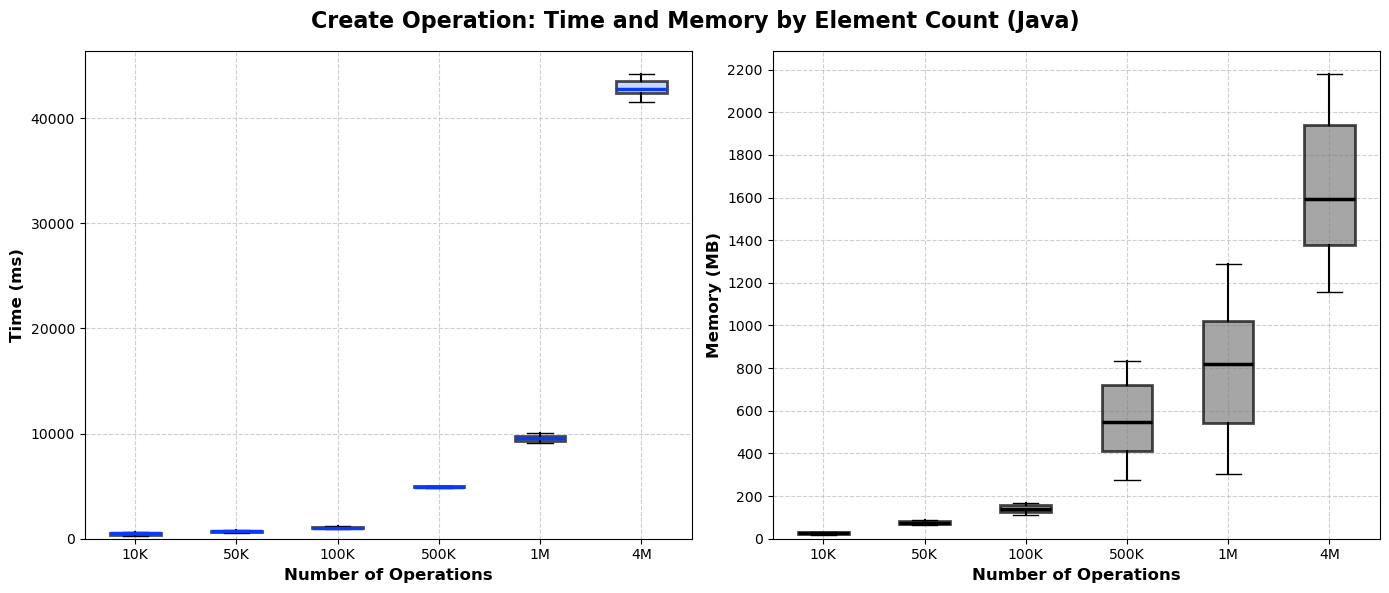

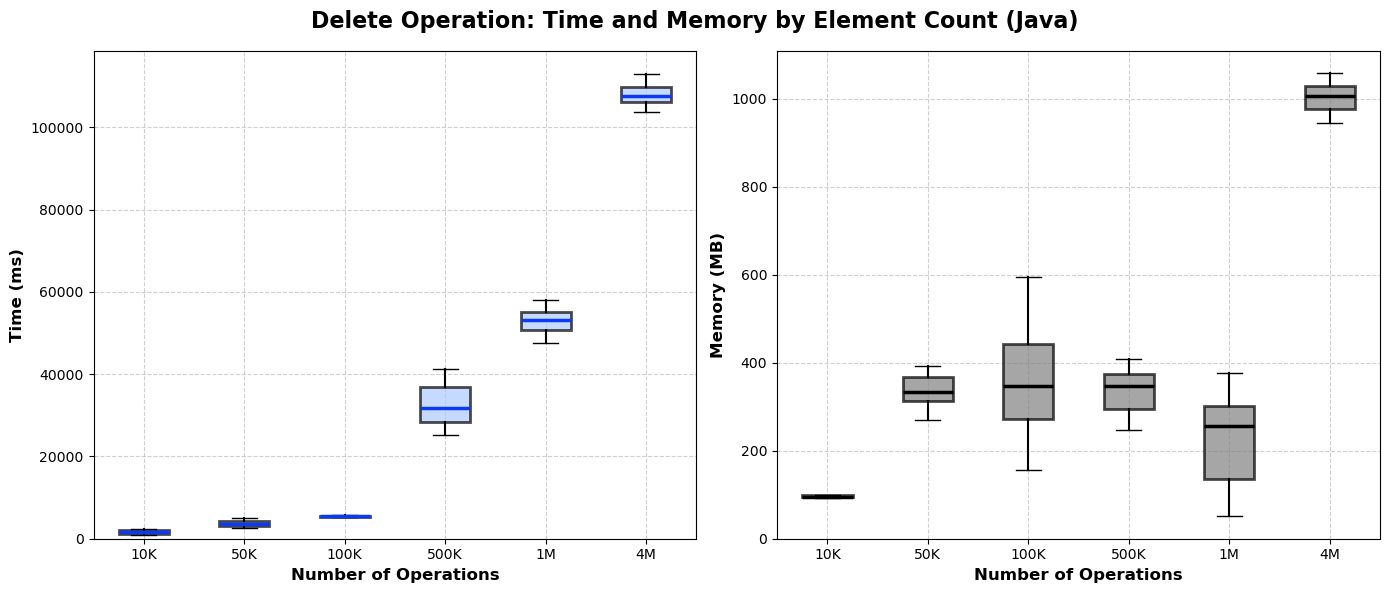

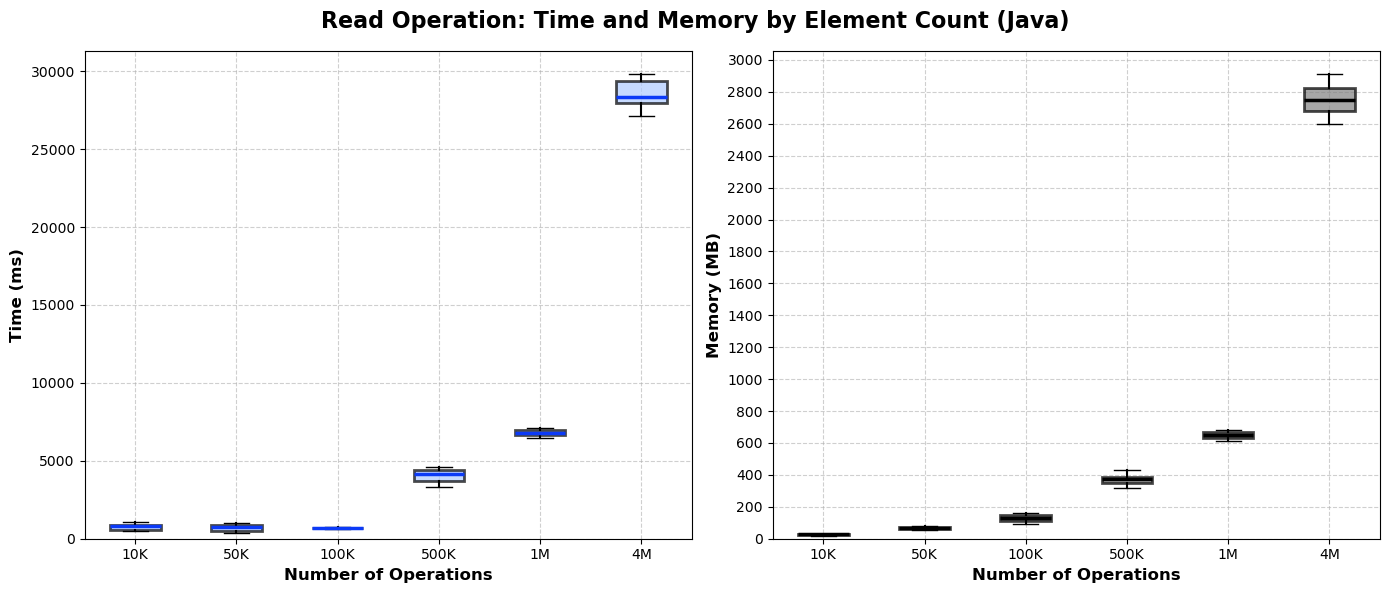

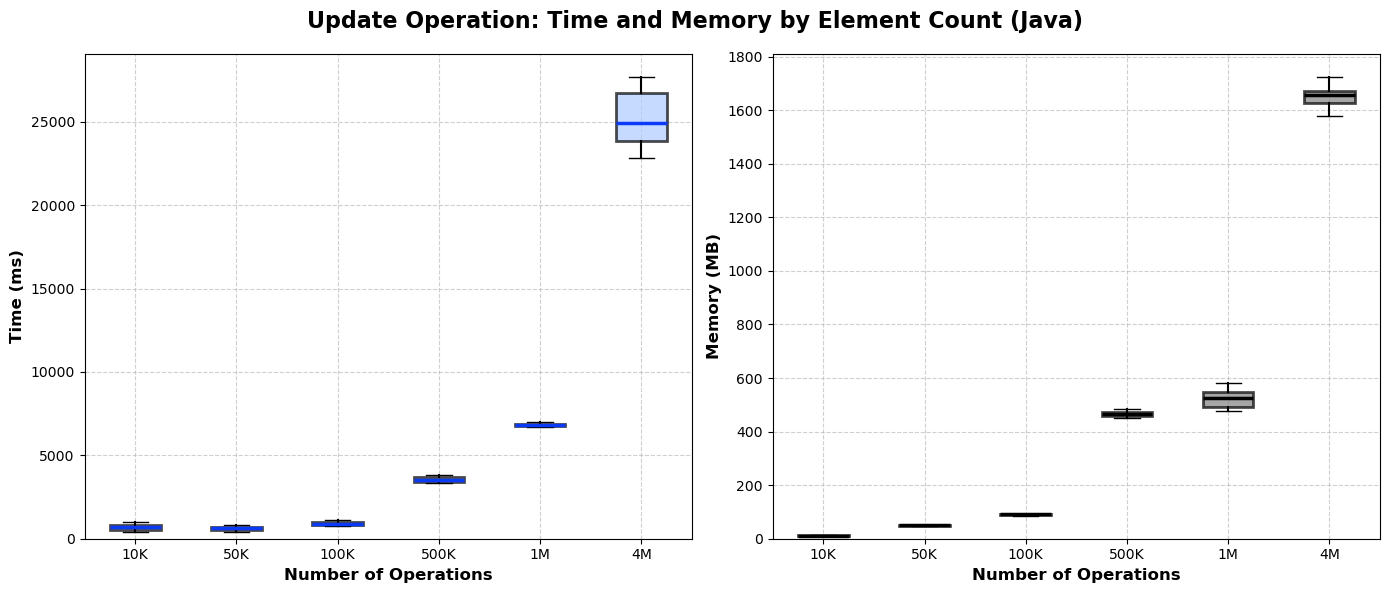

In [36]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

BASE_FOLDER = "../results/RQ3Models-reverse/"

group_col = "element_count"
pattern = re.compile(r"(.+)_run_\d+\.csv")


def plot_operation(df, op_name, metamodel_name):
    #df["time"] = df["time"] / 1000  
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # -------- TIME --------
    df.boxplot(
        column="time",
        by=group_col,
        ax=axes[0],
        patch_artist=True,
        showfliers=False,
        boxprops=dict(facecolor="#AFCBFF", color="black", linewidth=2, alpha=0.7),
        medianprops=dict(color="#0B3AF7", linewidth=2.5),
        whiskerprops=dict(color="black", linewidth=1.5),
    )

    axes[0].set_title("")
    axes[0].set_xlabel("Number of Operations", fontsize=12, fontweight="bold")
    axes[0].set_ylabel("Time (ms)", fontsize=12, fontweight="bold")
    axes[0].grid(True, linestyle="--", alpha=0.6)
    axes[0].set_ylim(bottom=0)

    # -------- MEM --------
    df.boxplot(
        column="mem",
        by=group_col,
        ax=axes[1],
        patch_artist=True,
        showfliers=False,
        boxprops=dict(facecolor="gray", color="black", linewidth=2, alpha=0.7),
        medianprops=dict(color="black", linewidth=2.5),
        whiskerprops=dict(color="black", linewidth=1.5),
    )

    axes[1].set_xlabel("Number of Operations", fontsize=12, fontweight="bold")
    axes[1].set_ylabel("Memory (MB)", fontsize=12, fontweight="bold")

    axes[1].yaxis.set_major_locator(mticker.MultipleLocator(200 * 1024))
    axes[1].yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"{int(x / 1024)}")
    )

    axes[1].grid(True, linestyle="--", alpha=0.6)
    axes[1].set_ylim(bottom=0)
    axes[1].set_title("")

    shorten_x_axis_labels(axes[0])
    shorten_x_axis_labels(axes[1])
    axes[0].set_ylim(bottom=0)
    axes[1].set_ylim(bottom=0)

    plt.suptitle(
        f"{op_name} Operation: Time and Memory by Element Count ({metamodel_name})",
        fontsize=16,
        fontweight="bold",
    )

    plt.tight_layout()

    plt.show()


# ---------------- main loop -

operations = {}

for metamodel in os.listdir(BASE_FOLDER):
    folder_path = os.path.join(BASE_FOLDER, metamodel)

    if not os.path.isdir(folder_path):
        continue
 

    for file in os.listdir(folder_path):
        if not file.endswith(".csv"):
            continue

        match = pattern.match(file)
        if not match:
            continue

        op = match.group(1)

        df = pd.read_csv(os.path.join(folder_path, file))
        df["metamodel"] = metamodel  # kept for traceability (not used in plot)

        operations.setdefault(op, []).append(df)


for op, dfs in operations.items():
    full_df = pd.concat(dfs, ignore_index=True)

    # all metamodels combined
    plot_operation(full_df, op, "Java")

In [39]:
import os
import re
import pandas as pd

BASE_FOLDER = "../results/RQ3Models-reverse/"

group_col = "element_count"
pattern = re.compile(r"(.+)_run_\d+\.csv")


# ---- Helper ----
def remove_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    return series[(series >= q1 - 1.5 * iqr) & (series <= q3 + 1.5 * iqr)]


# ---- LOAD DATA ----
operations = {}

for metamodel in os.listdir(BASE_FOLDER):
    folder_path = os.path.join(BASE_FOLDER, metamodel)

    if not os.path.isdir(folder_path):
        continue

    for file in os.listdir(folder_path):
        if not file.endswith(".csv"):
            continue

        match = pattern.match(file)
        if not match:
            continue

        op = match.group(1)

        df = pd.read_csv(os.path.join(folder_path, file))
        df["metamodel"] = metamodel

        operations.setdefault(op, []).append(df)


# ---- ANALYSIS ----
for op, dfs in operations.items():
    print("\n===================================================")
    print(f"OPERATION: {op}")
    print("===================================================\n")

    df = pd.concat(dfs, ignore_index=True)

    # ---- GLOBAL ----
    print("---- GLOBAL STATS ----")
    for metric in ["time", "mem"]:
        s = df[metric]
        print(f"{metric.upper()}: mean={s.mean():.4f}, median={s.median():.4f}, std={s.std():.4f}, max={s.max():.4f}")
    print()
 

    # ---- PER ELEMENT COUNT ----
    print("---- PER ELEMENT COUNT ----")
    grouped = df.groupby(group_col)

    for val, group in grouped:
        t_mean = remove_outliers(group["time"]).mean()
        m_mean = remove_outliers(group["mem"]).mean()
        print(f"{group_col}={val}: time_mean={t_mean:.4f}, mem_mean={m_mean:.4f}")
    print()
 
    # ---- PER METAMODEL ----
    print("---- PER METAMODEL ----")
    grouped_meta = df.groupby("metamodel")

    for name, group in grouped_meta:
        t_mean = remove_outliers(group["time"]).mean()
        m_mean = remove_outliers(group["mem"]).mean()
        print(f"{name}: time_mean={t_mean:.4f}, mem_mean={m_mean:.4f}, samples={len(group)}")
    print()

    # ---- WORST CASES (PER OPERATION TYPE) ----
    print("---- TOP 5 WORST CASES PER OPERATION TYPE ----")

    metrics = ["time", "mem"]

    for op_type in operations.keys():  # Create / Delete / Update / Read
        print(f"\n================ OPERATION: {op_type} ================")

        df_op = pd.concat(operations[op_type], ignore_index=True)

        for metric in metrics:
            print(f"\nWorst 5 by {metric}:")

            # take more candidates to allow dedup across time/mem later if needed
            candidates = df_op.nlargest(15, metric)

            selected = []
            seen = set()

            for _, row in candidates.iterrows():
                key = (row["metamodel"], row[group_col], row["time"], row["mem"])

                if key in seen:
                    continue

                seen.add(key)
                selected.append(row)

                if len(selected) == 5:
                    break

            result_df = pd.DataFrame(selected)[
                ["metamodel", group_col, "time", "mem"]
            ]

            print(result_df.to_string(index=False))


OPERATION: Create

---- GLOBAL STATS ----
TIME: mean=9927.9556, median=3002.5000, std=15104.5092, max=44176.0000
MEM: mean=554882.6333, median=227304.0000, std=611644.7122, max=2231516.0000

---- PER ELEMENT COUNT ----
element_count=10000: time_mean=470.0667, mem_mean=26756.9000
element_count=50000: time_mean=713.0000, mem_mean=77998.2667
element_count=100000: time_mean=1061.2667, mem_mean=145127.7000
element_count=500000: time_mean=4923.9333, mem_mean=578566.9333
element_count=1000000: time_mean=9569.9000, mem_mean=818727.0333
element_count=4000000: time_mean=42829.5667, mem_mean=1682118.9667

---- PER METAMODEL ----
java: time_mean=3347.6333, mem_mean=481359.3198, samples=180

---- TOP 5 WORST CASES PER OPERATION TYPE ----

================ OPERATION: Create ================

Worst 5 by time:
metamodel  element_count  time     mem
     java        4000000 44176 2231516
     java        4000000 43951 1458409
     java        4000000 43821 1776132
     java        4000000 43701 209791

In [37]:
import pandas as pd
import numpy as np
import glob
import os
import re
from collections import defaultdict, Counter

base_folder = "../results/RQ3Models-reverse/"
files = glob.glob(os.path.join(base_folder, "**/*.csv"), recursive=True)

pattern = re.compile(r"(.+)_run_\d+\.csv")

# ----------------------------
# GROUP BY OPERATION + METAMODEL
# ----------------------------
grouped = defaultdict(lambda: defaultdict(list))

for f in files:
    filename = os.path.basename(f)
    match = pattern.match(filename)
    if not match:
        continue

    op = match.group(1)
    metamodel = os.path.basename(os.path.dirname(f))

    grouped[op][metamodel].append(f)

print("Files:", len(files))
print("Operations:", len(grouped))


# ----------------------------
# MODELS
# ----------------------------
def r2(y, y_pred):
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    return 1 - ss_res / ss_tot


def fit_linear(x, y):
    A = np.vstack([x, np.ones(len(x))]).T
    coef, _, _, _ = np.linalg.lstsq(A, y, rcond=None)
    return coef, coef[0] * x + coef[1]


def fit_exponential(x, y):
    y_safe = np.where(y <= 0, 1e-9, y)
    logy = np.log(y_safe)
    A = np.vstack([x, np.ones(len(x))]).T
    coef, _, _, _ = np.linalg.lstsq(A, logy, rcond=None)
    b, loga = coef
    a = np.exp(loga)
    return (a, b), a * np.exp(b * x)


def fit_poly(x, y, degree):
    coef = np.polyfit(x, y, degree)
    return coef, np.polyval(coef, x)


def model_complexity(name):
    if name == "linear":
        return 1
    if name == "exponential":
        return 2
    if name.startswith("poly"):
        return int(name.replace("poly", ""))
    return 10


def format_poly(coefs):
    terms = []
    degree = len(coefs) - 1
    for i, c in enumerate(coefs):
        power = degree - i
        if power == 0:
            terms.append(f"{c:.6e}")
        elif power == 1:
            terms.append(f"{c:.6e} * x")
        else:
            terms.append(f"{c:.6e} * x^{power}")
    return " + ".join(terms)


# ----------------------------
# CONFIG
# ----------------------------
metrics = ["time", "mem"]
poly_degrees = [2, 3, 4, 5]

folder_summaries = []


# ----------------------------
# MAIN LOOP
# ----------------------------
for op, meta_map in grouped.items():
    for metamodel, flist in meta_map.items():

        for metric in metrics:

            run_results = []
            per_run_best = []
            per_run_scores = []
            file_scores = []

            coefs_linear = []
            coefs_exp = []
            coefs_poly = {d: [] for d in poly_degrees}

            for f in flist:
                df = pd.read_csv(f)

                x = df["element_count"].values
                y = df[metric].values

                scores = {}

                # ---- models ----
                _, y_lin = fit_linear(x, y)
                scores["linear"] = r2(y, y_lin)

                _, y_exp = fit_exponential(x, y)
                scores["exponential"] = r2(y, y_exp)

                for d in poly_degrees:
                    _, y_poly = fit_poly(x, y, d)
                    scores[f"poly{d}"] = r2(y, y_poly)

                run_results.append(scores)
                per_run_scores.append(scores)
                file_scores.append((f, scores))

                # best model per run
                rounded_scores = {k: round(v, 2) for k, v in scores.items()}
                max_score = max(rounded_scores.values())
                candidates = [k for k, v in rounded_scores.items() if v == max_score]
                best = min(candidates, key=model_complexity)
                per_run_best.append(best)

                # coefficients
                lin_coef, _ = fit_linear(x, y)
                exp_coef, _ = fit_exponential(x, y)

                coefs_linear.append(lin_coef)
                coefs_exp.append(exp_coef)

                for d in poly_degrees:
                    coef, _ = fit_poly(x, y, d)
                    coefs_poly[d].append(coef)

            # ----------------------------
            # AGGREGATION
            # ----------------------------
            df_runs = pd.DataFrame(run_results)
            mean_scores = df_runs.mean()

            mean_lin = np.mean(coefs_linear, axis=0)
            mean_exp = np.mean(coefs_exp, axis=0)
            mean_poly = {d: np.mean(coefs_poly[d], axis=0) for d in poly_degrees}

            counts = Counter(per_run_best)
            best_model = counts.most_common(1)[0][0]
            consistency = counts[best_model] / len(per_run_best)

            eq_linear = f"y = {mean_lin[0]:.6e} * x + {mean_lin[1]:.6e}"
            eq_exp = f"y = {mean_exp[0]:.6e} * exp({mean_exp[1]:.6e} * x)"
            eq_polys = {f"poly{d}": f"y = {format_poly(mean_poly[d])}" for d in poly_degrees}

            equation = {
                "linear": eq_linear,
                "exponential": eq_exp,
                **eq_polys
            }

            # ----------------------------
            # WORST CASE (FIXED)
            # ----------------------------
            worst_file, worst_scores = min(
                file_scores,
                key=lambda x: x[1][best_model]
            )

            worst_model = min(worst_scores, key=worst_scores.get)

            # ----------------------------
            # OUTPUT
            # ----------------------------
            print("\n==============================")
            print("Operation:", op)
            print("Metamodel:", metamodel)
            print("Metric:", metric.upper())

            print("Best model (majority vote):", best_model)
            print("Consistency:", consistency)

            print("\nEquations:")
            for k, v in equation.items():
                print(f"  {k}: {v}")

            print("\nMean R²:")
            print(mean_scores)

            if consistency < 1.0:
                print("\n⚠️ Inconsistent runs")
                print("Per-run best:", per_run_best)
                print("Worst file:", os.path.basename(worst_file))
                print("Worst model in worst file:", worst_model)
                print("Worst scores:", worst_scores)

            folder_summaries.append({
                "operation": op,
                "metamodel": metamodel,
                "metric": metric,
                "best_model": best_model,
                "consistency": consistency,
                "linear_r2": mean_scores["linear"],
                "exponential_r2": mean_scores["exponential"],
                **{f"poly{d}_r2": mean_scores[f"poly{d}"] for d in poly_degrees},
                "worst_file": os.path.basename(worst_file),
                "worst_model": worst_model
            })


# ----------------------------
# SAVE SUMMARY
# ----------------------------
summary_df = pd.DataFrame(folder_summaries)
summary_df.to_csv("RQ3_reverse_trend_analysis.csv", index=False)

print("\nSaved: RQ3_reverse_trend_analysis.csv")

Files: 120
Operations: 4

Operation: Create
Metamodel: java
Metric: TIME
Best model (majority vote): linear
Consistency: 1.0

Equations:
  linear: y = 1.067691e-02 * x + -1.439315e+02
  exponential: y = 1.164235e+03 * exp(9.973829e-07 * x)
  poly2: y = 4.402758e-10 * x^2 + 8.873404e-03 * x + 2.906608e+02
  poly3: y = 6.592787e-17 * x^3 + 1.135062e-10 * x^2 + 9.130272e-03 * x + 2.728928e+02
  poly4: y = 1.756509e-21 * x^4 + -9.601165e-15 * x^3 + 1.160207e-08 * x^2 + 5.397421e-03 * x + 4.150630e+02
  poly5: y = 1.125839e-28 * x^5 + 1.125291e-21 * x^4 + -8.803159e-15 * x^3 + 1.129789e-08 * x^2 + 5.422573e-03 * x + 4.147199e+02

Mean R²:
linear         0.998861
exponential    0.669215
poly2          0.999956
poly3          0.999969
poly4          0.999995
poly5          1.000000
dtype: float64

Operation: Create
Metamodel: java
Metric: MEM
Best model (majority vote): poly3
Consistency: 0.5666666666666667

Equations:
  linear: y = 3.954038e-01 * x + 1.818851e+05
  exponential: y = 1.187494e

In [38]:
import pandas as pd

df = pd.read_csv("RQ3_reverse_trend_analysis.csv")

summary = df.groupby("best_model").agg(
    occurrences=("best_model", "count"),
    operations=("operation", lambda x: sorted(x.unique())),
    metamodels=("metamodel", lambda x: sorted(x.unique()))
).reset_index()

for _, row in summary.iterrows():
    ops = ", ".join(row["operations"])
    metas = ", ".join(row["metamodels"])

    print(f"\n{row['best_model']} was found {row['occurrences']} times")
    print(f"  Operations: {ops}")
    print(f"  Metamodels: {metas}")


linear was found 4 times
  Operations: Create, Read, Update
  Metamodels: java

poly2 was found 1 times
  Operations: Delete
  Metamodels: java

poly3 was found 2 times
  Operations: Create, Update
  Metamodels: java

poly5 was found 1 times
  Operations: Delete
  Metamodels: java
